# LOADING FILES FROM SERVER AND EVALUATE

#### From your WSL terminal (not SCITAS)
cd /path/to/your/local/project

#### Create a directory for the model
mkdir models

#### Download the model checkpoint and training plot
scp -r wan@kuma.hpc.epfl.ch:/home/wan/opp_f/models/ /mnt/c/Users/Jiasheng/OneDrive/Documents/EPFL/ML\ for\ PREDICTIVE\ MAINTENANCE/Project/MLPM/SERVERFILES

#### Load new files to server
scp "/mnt/c/Users/Jiasheng/OneDrive/Documents/EPFL/ML for PREDICTIVE MAINTENANCE/Project/MLPM/SERVERFILES/train.py" wan@kuma.hpc.epfl.ch:/home/wan/opp_f/

In [1]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
import os
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from dataclasses import dataclass
import pyarrow.parquet as pq
from traincae import DEFAULT_PARAMS, CAE, SlidingWindowDataset, Operating_modes_name, preprocess_hydraulic_data
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
dataset_root = Path(r"../dataset") # Raw string works without escaping \

@dataclass
class Case():
    info: pd.DataFrame
    measurements: pd.DataFrame


class RawDataset():

    def __init__(self, root, unit = "VG4", load_training=False, load_synthetic=False) -> None:
        
        
        read_pq_file = lambda f: pq.read_table(root / f).to_pandas()
        
        
        cases = {
            "test": [f"{unit}_generator_data_testing_real_measurements.parquet", root / f"{unit}_generator_data_testing_real_info.csv" ], 
        }
        
        if load_training:
            cases = {
                **cases,
                "train": [f"{unit}_generator_data_training_measurements.parquet", root / f"{unit}_generator_data_training_info.csv" ], 
            }
        
        if load_synthetic:
            cases = {
                **cases,
                "test_s01": [f"{unit}_generator_data_testing_synthetic_01_measurements.parquet", root / f"{unit}_generator_data_testing_synthetic_01_info.csv"], 
                "test_s02": [f"{unit}_generator_data_testing_synthetic_02_measurements.parquet", root / f"{unit}_generator_data_testing_synthetic_02_info.csv"]
            }
        
        
        self.data_dict = dict()
        
        for id_c, c in cases.items():
            # if you need to verify the parquet header:
            # pq_rows = RawDataset.read_parquet_schema_df(root / c[0])
            info = pd.read_csv(c[1])
            measurements = read_pq_file(c[0])
            self.data_dict[id_c] = Case(info, measurements)
            
        
        
    @staticmethod
    def read_parquet_schema_df(uri: str) -> pd.DataFrame:
        """Return a Pandas dataframe corresponding to the schema of a local URI of a parquet file.

        The returned dataframe has the columns: column, pa_dtype
        """
        # Ref: https://stackoverflow.com/a/64288036/
        schema = pq.read_schema(uri, memory_map=True)
        schema = pd.DataFrame(({"column": name, "pa_dtype": str(pa_dtype)} for name, pa_dtype in zip(schema.names, schema.types)))
        schema = schema.reindex(columns=["column", "pa_dtype"], fill_value=pd.NA)  # Ensures columns in case the parquet file has an empty dataframe.
        return schema

## CAE Evaluation Fucntion

In [3]:
def obtain_ground_truth(dataset_root, unit="VG5", test_set="01", anomaly_type="a"):

    # Load anomaly data
    anomaly_file = Path(dataset_root) / "synthetic_anomalies" / f"{unit}_anomaly_{test_set}_type_{anomaly_type}.parquet"
    anomaly_data = pq.read_table(anomaly_file).to_pandas()
    ground_truth = anomaly_data['ground_truth']
    ground_truth_index = anomaly_data.index
    
    return ground_truth, ground_truth_index

def plot_ground_truth(ground_truth, ground_truth_index, unit, test_set, anomaly_type):
    """Plot ground truth data"""
    plt.figure(figsize=(15, 4))
    plt.plot(ground_truth_index, ground_truth, 'b-', linewidth=1)
    
    plt.title(f'Ground Truth - {unit}, Set {test_set}, Type {anomaly_type}')
    plt.ylim(-0.1, 1.1)
    plt.grid(True)
    plt.xlabel('Time')
    plt.ylabel('Anomaly Present')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

def evaluate_autoencoder(model, test_loader, n_control_features, affected_sensor_indices=None, device='cpu'):
    """
    Evaluate autoencoder performance with focus on affected sensors
    
    Args:
        model: trained CAE model
        test_loader: DataLoader for test data
        n_control_features: number of control features
        affected_sensor_indices: list of indices for sensors affected by anomalies
        device: computation device
    """
    model.eval()
    reconstruction_errors = []
    predictions = []
    actuals = []
    
    # If no specific sensors are specified, evaluate all
    if affected_sensor_indices is None:
        affected_sensor_indices = slice(None)  # all sensors
    
    with torch.no_grad():
        for x, _ in tqdm(test_loader, desc="Evaluating"):
            x = x.to(device)
            sensor_part = x[:, n_control_features:, :]
            
            # Get reconstruction
            reconstruction = model(x)
            
            # Store results for affected sensors only
            predictions.append(reconstruction[:, affected_sensor_indices, :].cpu().numpy())
            actuals.append(sensor_part[:, affected_sensor_indices, :].cpu().numpy())
            
            # Calculate reconstruction error for affected sensors only
            error = torch.mean(
                (reconstruction[:, affected_sensor_indices, :] - 
                 sensor_part[:, affected_sensor_indices, :]) ** 2,
                dim=2
            )
            reconstruction_errors.extend(error.cpu().numpy())
    
    return np.array(reconstruction_errors), np.concatenate(predictions), np.concatenate(actuals)

def check_scaling_ranges(original_data, scaled_data, sensor_ranges, sensor_names):
    """
    Check if test data exceeds training ranges
    
    Args:
        original_data: original test data
        scaled_data: scaled test data
        sensor_ranges: ranges from training data
        sensor_names: names of sensors
    """
    print("\nScaling Range Analysis:")
    print("-" * 50)
    
    exceeding_sensors = []
    
    for i, sensor in enumerate(sensor_names):
        orig_min = original_data[:, i].min()
        orig_max = original_data[:, i].max()
        scaled_min = scaled_data[:, i].min()
        scaled_max = scaled_data[:, i].max()
        
        train_min = sensor_ranges[i]['min']
        train_max = sensor_ranges[i]['max']
        
        if scaled_min < 0 or scaled_max > 1:
            exceeding_sensors.append(sensor)
            print(f"\nSensor: {sensor}")
            print(f"Training range: [{train_min:.3f}, {train_max:.3f}]")
            print(f"Test range: [{orig_min:.3f}, {orig_max:.3f}]")
            print(f"Scaled range: [{scaled_min:.3f}, {scaled_max:.3f}]")
    
    return exceeding_sensors


def evaluate_cae_anomaly_detection(model, test_loader, ground_truth, n_control_features, threshold=None):
    """
    Evaluate CAE model performance for anomaly detection.
    
    Args:
        model: trained CAE model
        test_loader: DataLoader with test data
        ground_truth: array of true labels (0 for normal, 1 for anomaly)
        n_control_features: number of control features
        threshold: anomaly threshold (if None, will be determined using ROC curve)
    """
    model.eval()
    reconstruction_errors = []
    
    # Compute reconstruction errors
    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(next(model.parameters()).device)
            sensor_input = x[:, n_control_features:, :]
            reconstruction = model(x)
            error = torch.mean((reconstruction - sensor_input) ** 2, dim=2)
            reconstruction_errors.extend(error.cpu().numpy())
    
    reconstruction_errors = np.array(reconstruction_errors)
    

    ## Compute ROC curve and find optimal threshold
    #fpr, tpr, thresholds = roc_curve(ground_truth, reconstruction_errors)
    #roc_auc = auc(fpr, tpr)
    #
    ## Find optimal threshold using Youden's J statistic
    #optimal_idx = np.argmax(tpr - fpr)
    #optimal_threshold = thresholds[optimal_idx]
    #
    ## Use provided threshold or optimal threshold
    #final_threshold = threshold if threshold is not None else optimal_threshold
    #
    ## Make predictions using the threshold
    #predictions = (reconstruction_errors > final_threshold).astype(int)
    #
    ## Compute confusion matrix
    #cm = confusion_matrix(ground_truth, predictions)
    #
    ## Get classification report
    #report = classification_report(ground_truth, predictions)
    
    return {
        'reconstruction_errors': reconstruction_errors,
        'ground_truth': ground_truth,
        #'predictions': predictions,
        #'roc_curve': (fpr, tpr, roc_auc),
        #'threshold': final_threshold,
        #'confusion_matrix': cm,
        #'classification_report': report
    }

def plot_evaluation_results(results, target_columns=None):
    """
    Plot evaluation results including ROC curves and confusion matrix.
    
    Args:
        results: dictionary containing evaluation results
        target_columns: list of column names with injected anomalies
    """
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot ROC curve
    fpr, tpr, roc_auc = results['roc_curve']
    ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('Receiver Operating Characteristic')
    ax1.legend(loc="lower right")
    ax1.grid(True)
    
    # Plot confusion matrix
    sns.heatmap(results['confusion_matrix'], annot=True, fmt='d', cmap='Blues', ax=ax2)
    ax2.set_title('Confusion Matrix')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('True')
    
    plt.tight_layout()
    plt.show()
    
    # Print classification report
    print("\nClassification Report:")
    print(results['classification_report'])
    
    if target_columns:
        # Additional analysis for target columns
        print("\nReconstruction Error Statistics for Target Sensors:")
        errors = results['reconstruction_errors']
        truth = results['ground_truth']
        
        normal_errors = errors[truth == 0]
        anomaly_errors = errors[truth == 1]
        
        print(f"\nNormal samples:")
        print(f"Mean error: {normal_errors.mean():.6f}")
        print(f"Std error: {normal_errors.std():.6f}")
        
        print(f"\nAnomaly samples:")
        print(f"Mean error: {anomaly_errors.mean():.6f}")
        print(f"Std error: {anomaly_errors.std():.6f}")

## Running the code

In [4]:
# Your existing paths
base_path = Path("./")
dataset_path = Path("../Dataset")
model_path = base_path / "models/best_cae_model.pth"

# Load model and parameters
checkpoint = torch.load(model_path, map_location=device)
DEFAULT_PARAMS = checkpoint['params']

operating_conditions_set = {
    "dyn_only_on": False, "turbine_mode": True, "equilibrium_turbine_mode": True, "short_circuit_mode": False
}

# LOAD PARAMETERS
SYNTHETIC_PARAMS = {
    'unit': 'VG5',
    'test_set': '02',
    'anomaly_type': 'a',
    'set_type':'test_s02'
}

# Load parameters directly from checkpoint
DEFAULT_PARAMS = checkpoint['params']  # This contains all the parameters used during training

# Load only synthetic test data (no training data needed)
rds_u5_synth = RawDataset(dataset_root, "VG5", load_synthetic=True, load_training=False)

# Process synthetic datasets
processed_test_data = preprocess_hydraulic_data(
    rds_u5_synth, 
    set_type=SYNTHETIC_PARAMS['set_type'], 
    operating_conditions=operating_conditions_set, 
        scaler_control=None,
        scaler_sensors=None,  # your loaded scaler
    fit = False
)

control_df = processed_test_data['control_signals']
sensors_df = processed_test_data['sensor_signals']

selected_groups = ['stator_temperature', 'cooling_system', 'heat_exchanger']
sensor_groups = {
    'stator_temperature': sensors_df[1],
    'cooling_system': sensors_df[2],
    'heat_exchanger': sensors_df[3]
}

# Load scaler_control.pkl from the data folder
with open('models/scaler_control_cae.pkl', 'rb') as file:
    scaler_control = pickle.load(file)

# Load scaler_sensor.pkl from the data folder
with open('models/scaler_sensors_cae.pkl', 'rb') as file:
    scaler_sensors = pickle.load(file)

# First combine selected sensors into one DataFrame
combined_sensors = pd.concat([sensor_groups[group] for group in selected_groups], axis=1)

# Normalize control and sensor data
control_df_normalized = pd.DataFrame(
    scaler_control.transform(control_df),
    columns=control_df.columns,
    index=control_df.index
)

sensors_df_normalized = pd.DataFrame(
    scaler_sensors.transform(combined_sensors),
    columns=combined_sensors.columns,
    index=combined_sensors.index
)

# Create dataset for evaluation
test_dataset = SlidingWindowDataset(
    control_df_normalized,
    sensors_df_normalized,
    window=DEFAULT_PARAMS['window_size'],
    device=device
)

# Create dataloader
test_loader = DataLoader(
    test_dataset,
    batch_size=DEFAULT_PARAMS['batch_size'],
    shuffle=False  # Important: keep order for anomaly detection
)

# Load your model
model = CAE(
    in_features=len(control_df.columns) + len(combined_sensors.columns),
    out_features=len(combined_sensors.columns),
    params=DEFAULT_PARAMS
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()


/tmp/ipykernel_16257/830812813.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


CAE(
  (encoder): Sequential(
    (0): Conv1d(60, 48, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Conv1d(48, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Conv1d(32, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): ConvTranspose1d(32, 48, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, tra

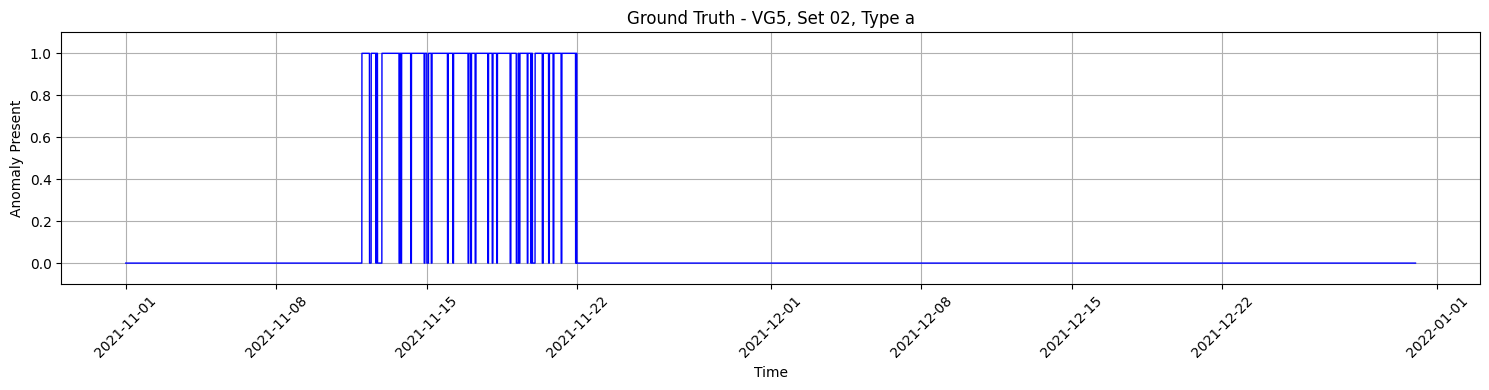

In [5]:
ground_truth, ground_truth_index = obtain_ground_truth(
    dataset_root,
    unit=SYNTHETIC_PARAMS['unit'],
    test_set=SYNTHETIC_PARAMS['test_set'],
    anomaly_type=SYNTHETIC_PARAMS['anomaly_type']
)

plot_ground_truth(
        ground_truth,
        ground_truth_index,
        unit=SYNTHETIC_PARAMS['unit'],
        test_set=SYNTHETIC_PARAMS['test_set'],
        anomaly_type=SYNTHETIC_PARAMS['anomaly_type']
    )

Test dataset length: 55835
Final ground truth length: 55835


KeyError: 'roc_curve'

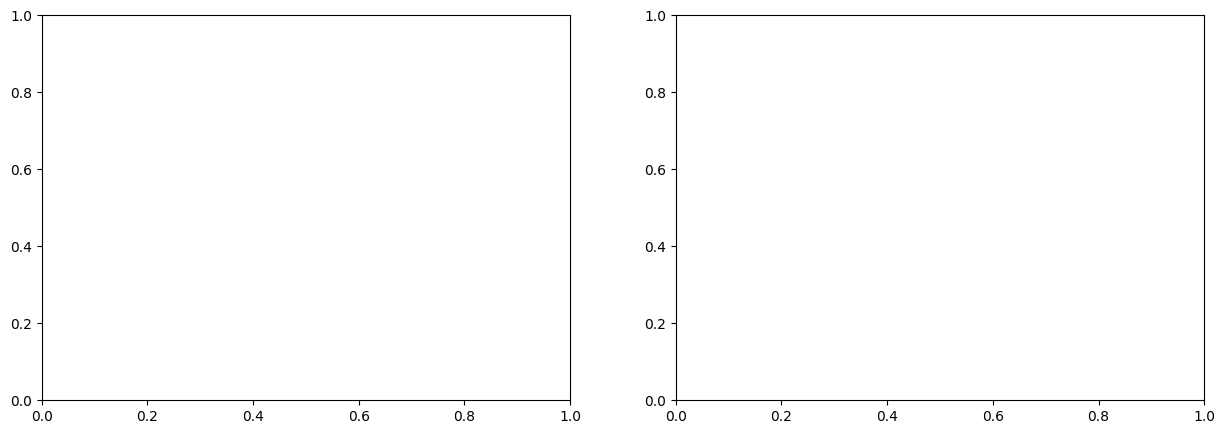

In [6]:
# 1. First do the timestamp alignment
ground_truth_series = pd.Series(ground_truth, index=ground_truth_index)
trimmed_ground_truth = ground_truth_series[
    (ground_truth_index >= combined_sensors.index[0]) & 
    (ground_truth_index <= combined_sensors.index[-1])
]
ground_truth_aligned = trimmed_ground_truth.reindex(combined_sensors.index, method='ffill')

# 2. Adjust for sliding windows to match the test dataset length
window_size = DEFAULT_PARAMS['window_size']
def adjust_aligned_ground_truth(ground_truth_aligned, window_size, target_length):
    """
    Adjust timestamp-aligned ground truth for sliding windows with exact length matching
    """
    valid_length = len(ground_truth_aligned) - window_size + 1
    adjusted_ground_truth = np.zeros(valid_length)
    
    for i in range(valid_length):
        window = ground_truth_aligned.iloc[i:i + window_size]
        adjusted_ground_truth[i] = 1 if any(window > 0) else 0
    
    # Ensure exact length match
    return adjusted_ground_truth[:target_length]

# 3. Create the final adjusted ground truth with exact length matching
final_ground_truth = adjust_aligned_ground_truth(
    ground_truth_aligned, 
    window_size,
    len(test_dataset)  # Pass the exact required length
)

# Verify lengths match exactly
print(f"Test dataset length: {len(test_dataset)}")
print(f"Final ground truth length: {len(final_ground_truth)}")
assert len(final_ground_truth) == len(test_dataset), "Lengths still don't match!"

# 4. Now run the evaluation
results = evaluate_cae_anomaly_detection(
    model,
    test_loader,
    final_ground_truth,
    n_control_features=len(control_df.columns)
)

# 5. Plot the results
target_columns = ['water_circ_hot_tmp', 'stat_coil_ph03_05_tmp', 'air_circ_hot_02_tmp']
plot_evaluation_results(results, target_columns)

In [7]:
columns=[]

for key in sensor_groups.keys():
    columns.extend(sensor_groups[key].columns)

def find_indexes(main_list, subset_list):
    # Create a dictionary to store the indexes of each element in the main list
    index_dict = {value: idx for idx, value in enumerate(main_list)}
    
    # Find the indexes of elements in the subset list that are in the main list
    indexes = [index_dict[element] for element in subset_list if element in index_dict]
    
    return indexes

indexes_column = find_indexes(columns,target_columns)

In [8]:
target_columns_tuple = [(index,column) for (index,column) in zip(indexes_column,target_columns)]

In [9]:
target_columns_tuple

[(50, 'water_circ_hot_tmp'),
 (16, 'stat_coil_ph03_05_tmp'),
 (37, 'air_circ_hot_02_tmp')]

In [10]:
results = evaluate_cae_anomaly_detection(
    model,
    test_loader,
    final_ground_truth,
    n_control_features=len(control_df.columns)
)

In [11]:
# Computing the threshold for the signals

res_mean = np.mean(results["reconstruction_errors"],axis=1)
res_std = np.std(results["reconstruction_errors"],axis=1)

res_threshold = res_mean + 3*res_std
print(res_threshold)

[0.00031521 0.00031322 0.00031911 ... 0.00044698 0.00043604 0.00043143]


In [14]:
# Load synthetic data
synthetic_file_path = Path(dataset_root) / "synthetic_anomalies/VG5_anomaly_02_type_a.parquet"
synthetic_data = pd.read_parquet(synthetic_file_path)

# Extract ground truth
ground_truth = synthetic_data['ground_truth']
sensor_data = synthetic_data.drop('ground_truth', axis=1)

# Separate operating modes
operating_mode_columns = [
    "machine_on", "machine_off", "turbine_mode", "all",
    "equilibrium_turbine_mode", "dyn_only_on", "pump_mode",
    "short_circuit_mode", "equilibrium_pump_mode",
    "equilibrium_short_circuit_mode"
]

# Filter data based on operating conditions
mode_mask = pd.Series([True] * len(sensor_data), index=sensor_data.index)
for mode, value in operating_conditions_set.items():
    mode_mask &= (sensor_data[mode] == value)

# Apply the filter
filtered_data = sensor_data[mode_mask]
filtered_ground_truth = ground_truth[mode_mask]

# Remove operating mode columns from sensor data
filtered_data = filtered_data.drop(operating_mode_columns, axis=1)

# Start with the same base control features
control_features = [
    'charge', 'coupler_position', 'pump_calculated_flow', 
    'pump_pressure_diff', 'pump_rotspeed', 'turbine_pressure', 
    'turbine_rotspeed'
]

rds_train = RawDataset(dataset_root, "VG5", load_synthetic=False, load_training=True)

training_data = preprocess_hydraulic_data(
    rds_train, 
    set_type="train",
    operating_conditions=operating_conditions_set,
    scaler_control=None,
    scaler_sensors=None,
    fit=False
)

# Extract and sum water opening features
water_opening_features = [col for col in filtered_data.columns if "water" in col.lower() and "opening" in col.lower()]
filtered_data['water_opening_sum'] = filtered_data[water_opening_features].sum(axis=1)
control_df['water_opening_sum'] = filtered_data['water_opening_sum']

# Extract and sum injector opening features
injector_opening_features = [col for col in filtered_data.columns if "injector" in col.lower() and "opening" in col.lower()]
filtered_data['injector_opening_sum'] = filtered_data[injector_opening_features].sum(axis=1)
control_df['injector_opening_sum'] = filtered_data['injector_opening_sum']

# Verify the result
print("\nUpdated Control Features:")
print("Shape:", control_df.shape)
print("Columns:", control_df.columns.tolist())

# Get sensor groups like in training
selected_groups = ['stator_temperature', 'cooling_system', 'heat_exchanger']


: 

In [12]:
from matplotlib.gridspec import GridSpec

def plot_detailed_per_sensor_analysis(model, test_loader, target_columns, ground_truth, reconstruction_errors, n_control_features, thresholds=None):
    """
    Create 9 subplots (3x3):
    For each target sensor:
    1. Synthetic vs Predicted datacolumn
    2. Ground truth
    3. Reconstruction error with threshold
    """
    model.eval()
    all_inputs = []
    all_predictions = []
    
    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(next(model.parameters()).device)
            prediction = model(x)
            all_inputs.append(x[:, n_control_features:, -1].cpu())
            all_predictions.append(prediction[:, :, -1].cpu())
    
    all_inputs = torch.cat(all_inputs, dim=0).numpy()
    all_predictions = torch.cat(all_predictions, dim=0).numpy()
    
    # Create figure with 9 subplots
    fig = plt.figure(figsize=(20, 15))
    gs = GridSpec(3, 3, figure=fig)
    
    id_thresh = 0

    for idx, col in enumerate(target_columns):
        col_idx = idx  # Assuming target columns are in order
        
        # 1. Synthetic vs predicted data
        ax1 = fig.add_subplot(gs[idx, 0])
        ax1.plot(all_inputs[:, col_idx], color='b', label='Synthetic', alpha=0.6)
        ax1.plot(all_predictions[:, col_idx], color='r', linestyle='--', 
                label='Predicted', alpha=0.6)
        ax1.set_title(f'{col}\nSynthetic vs Predicted')
        ax1.set_xlabel('Time Steps')
        ax1.set_ylabel('Normalized Value')
        ax1.legend()
        ax1.grid(True)
        
        # 2. Ground truth
        ax2 = fig.add_subplot(gs[idx, 1])
        ax2.plot(ground_truth, color='r', label='Ground Truth')
        ax2.set_title(f'{col}\nGround Truth')
        ax2.set_xlabel('Time Steps')
        ax2.set_ylabel('Anomaly')
        ax2.set_ylim(-0.1, 1.1)
        ax2.grid(True)
        
        # 3. Getting the correct thresholds
        threshold = thresholds[id_thresh]
        id_thresh+=1

        # 4. Reconstruction error
        ax3 = fig.add_subplot(gs[idx, 2])
        ax3.plot(reconstruction_errors, color='b', label='Error')
        if threshold is not None:
            ax3.axhline(y=threshold, color='r', linestyle='--', 
                       label=f'Threshold ({threshold:.6f})')
        ax3.set_title(f'{col}\nReconstruction Error')
        ax3.set_xlabel('Time Steps')
        ax3.set_ylabel('Error')
        ax3.legend()
        ax3.grid(True)
    
    plt.tight_layout()
    plt.show()

In [13]:

# First identify sensor columns for each group
stator_temp_columns = [col for col in sensors_df[1].columns if 'stat_' in col and ('coil' in col or 'magn' in col)]
cooling_system_columns = [col for col in sensors_df[2].columns if 'air_circ_' in col]
heat_exchanger_columns = [col for col in sensors_df[3].columns if 'water_circ_' in col]

sensor_groups = {
    'stator_temperature': filtered_data[stator_temp_columns],
    'cooling_system': filtered_data[cooling_system_columns],
    'heat_exchanger': filtered_data[heat_exchanger_columns]
}

# Combine selected sensors
combined_sensors = pd.concat([sensor_groups[group] for group in selected_groups], axis=1)

print("\nSensor Data Overview:")
print(f"Total sensor features: {combined_sensors.shape[1]}")
print(f"Stator temperature features: {len(stator_temp_columns)}")
print(f"Cooling system features: {len(cooling_system_columns)}")
print(f"Heat exchanger features: {len(heat_exchanger_columns)}")


# Load scaler_control.pkl from the data folder
with open('models/scaler_control_cae.pkl', 'rb') as file:
    scaler_control = pickle.load(file)

# Load scaler_sensor.pkl from the data folder
with open('models/scaler_sensors_cae.pkl', 'rb') as file:
    scaler_sensors = pickle.load(file)

# Normalize control and sensor data
control_df_normalized = pd.DataFrame(
    scaler_control.transform(control_df),
    columns=control_df.columns,
    index=control_df.index
)

sensors_df_normalized = pd.DataFrame(
    scaler_sensors.transform(combined_sensors),
    columns=combined_sensors.columns,
    index=combined_sensors.index
)

# Create dataset
test_dataset = SlidingWindowDataset(
    control_df_normalized,
    sensors_df_normalized,
    window=DEFAULT_PARAMS['window_size'],
    device=device
)

# Create dataloader
test_loader = DataLoader(
    test_dataset,
    batch_size=DEFAULT_PARAMS['batch_size'],
    shuffle=False
)

# Adjust ground truth for sliding window
def adjust_ground_truth_for_window(ground_truth, window_size):
    adjusted_length = len(ground_truth) - window_size
    adjusted_ground_truth = np.zeros(adjusted_length)
    
    for i in range(adjusted_length):
        window = ground_truth.iloc[i:i + window_size]
        adjusted_ground_truth[i] = 1 if any(window > 0) else 0
    
    return adjusted_ground_truth

# Adjust ground truth to match dataset length
final_ground_truth = adjust_ground_truth_for_window(
    filtered_ground_truth,
    window_size=DEFAULT_PARAMS['window_size']
)

# Verify lengths
print(f"\nLength check:")
print(f"Test dataset length: {len(test_dataset)}")
print(f"Adjusted ground truth length: {len(final_ground_truth)}")

# Run evaluation
results = evaluate_cae_anomaly_detection(
    model,
    test_loader,
    final_ground_truth,
    n_control_features=len(control_df.columns)
)

target_columns = ['water_circ_hot_tmp', 'stat_coil_ph03_05_tmp', 'air_circ_hot_02_tmp']
plot_evaluation_results(results, target_columns)


NameError: name 'filtered_data' is not defined

/tmp/ipykernel_16257/1014008539.py:70: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_16257/1014008539.py:70: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()
/home/matthieu/Documents/ML predictive maintenance/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


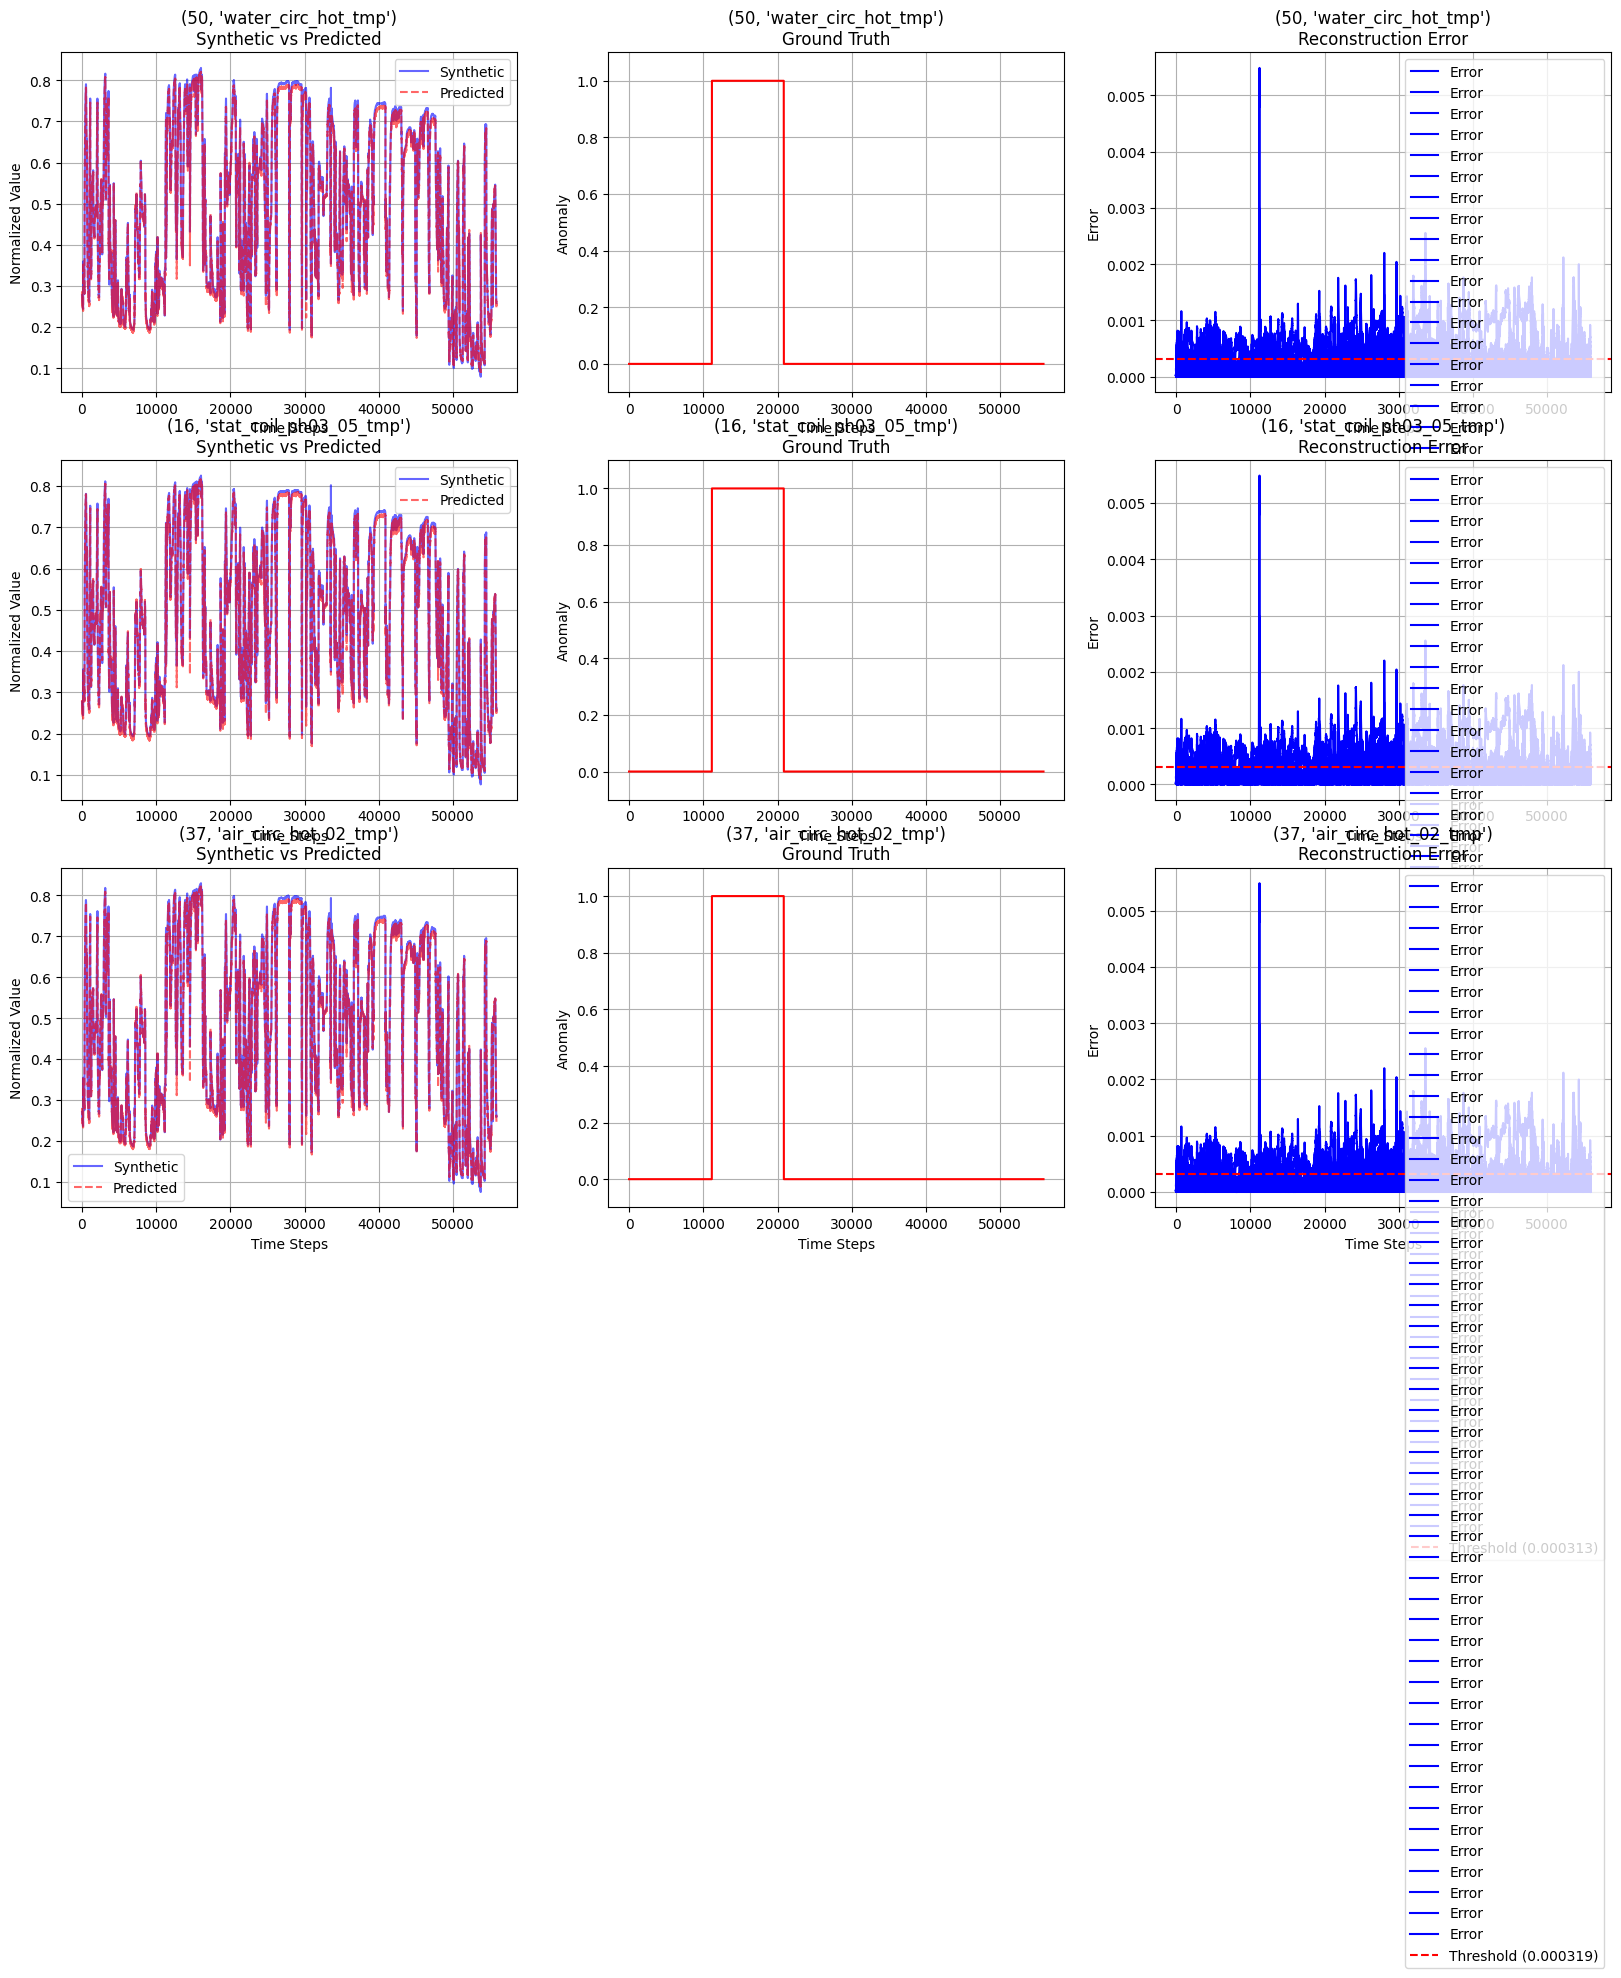

In [14]:
# Calculate threshold
mean_error = np.mean(results['reconstruction_errors'])
std_error = np.std(results['reconstruction_errors'])
threshold = 0.0005 # physically set it


# Create the visualization
plot_detailed_per_sensor_analysis(
    model=model,
    test_loader=test_loader,
    target_columns=target_columns_tuple,
    ground_truth=final_ground_truth,
    reconstruction_errors=results['reconstruction_errors'],
    n_control_features=len(control_df.columns),
    thresholds=res_threshold
)

In [18]:
rds_train = RawDataset(dataset_root, "VG5", load_synthetic=False, load_training=True)

train_case = rds_train.data_dict['train']

mean_value = train_case.measurements['water_circ_hot_tmp'].mean()
print("Mean value:", mean_value)

plt.figure(figsize=(16, 6))  # Adjust the width and height as needed
plt.plot(train_case.measurements['water_circ_hot_tmp'], label='Data')
plt.axhline(mean_value, color='red', linestyle='--', label=f'Mean: {mean_value:.2f}')
plt.title('Water Circ Hot Temp', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Value', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()  # Ensure everything fits well
plt.show()



: 

Mean value: 20.41592171605583

First few rows of 'water_circ_hot_tmp':
2021-11-01 00:00:00+01:00    24.810596
2021-11-01 00:00:30+01:00    24.820530
2021-11-01 00:01:00+01:00    24.830464
2021-11-01 00:01:30+01:00    24.840397
2021-11-01 00:02:00+01:00    24.850331
Name: water_circ_hot_tmp, dtype: float64


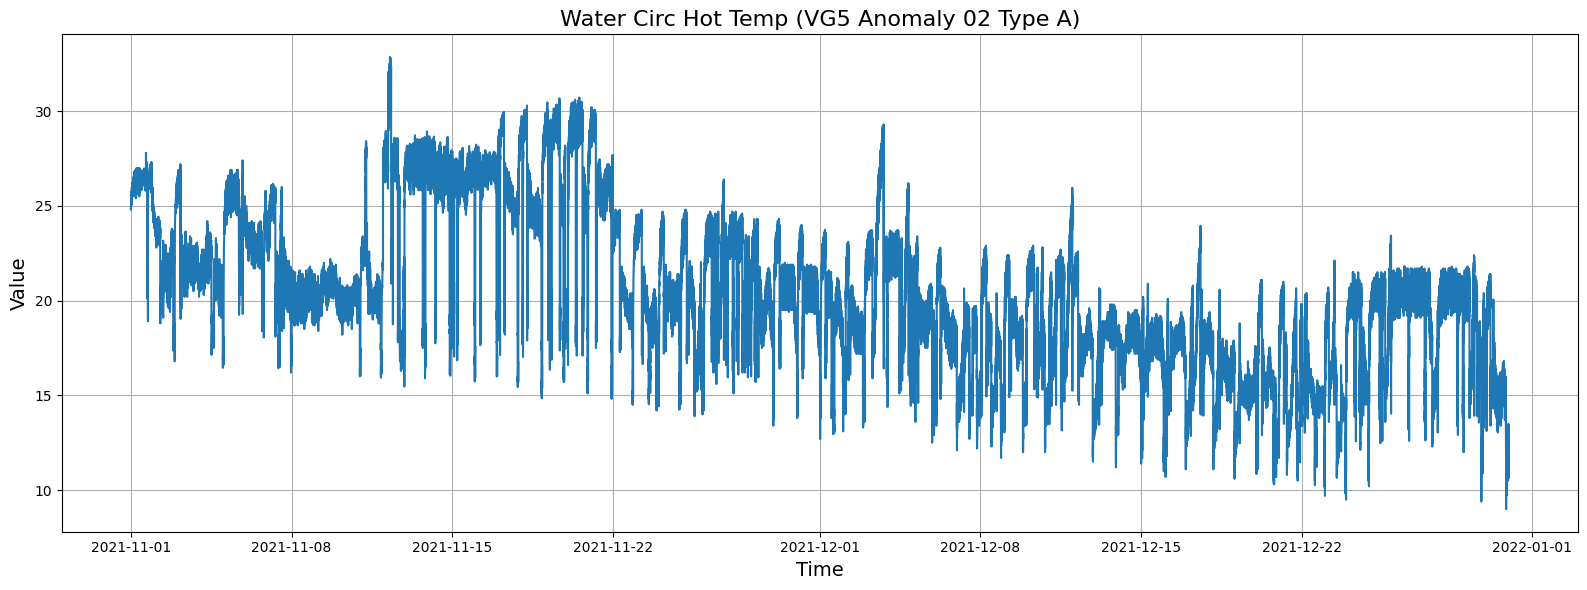

In [ ]:
# Define the file path
synthetic_file_path = Path(dataset_root) / "synthetic_anomalies/VG5_anomaly_02_type_a.parquet"

# Read the Parquet file
synthetic_data_2a = pd.read_parquet(synthetic_file_path)

# Check available columns
mean_value_test2 = synthetic_data_2a['water_circ_hot_tmp'].mean()
print("Mean value:", mean_value_test2)

# Check if 'water_circ_hot_tmp' exists
if 'water_circ_hot_tmp' in synthetic_data_2a.columns:
    print("\nFirst few rows of 'water_circ_hot_tmp':")
    print(synthetic_data_2a['water_circ_hot_tmp'].head())
    
    # Plot the 'water_circ_hot_tmp' column
    plt.figure(figsize=(16, 6))  # Adjust the figure size as needed
    plt.plot(synthetic_data_2a['water_circ_hot_tmp'])
    plt.title('Water Circ Hot Temp (VG5 Anomaly 02 Type A)', fontsize=16)
    plt.xlabel('Time', fontsize=14)
    plt.ylabel('Value', fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("'water_circ_hot_tmp' not found in the dataset.")


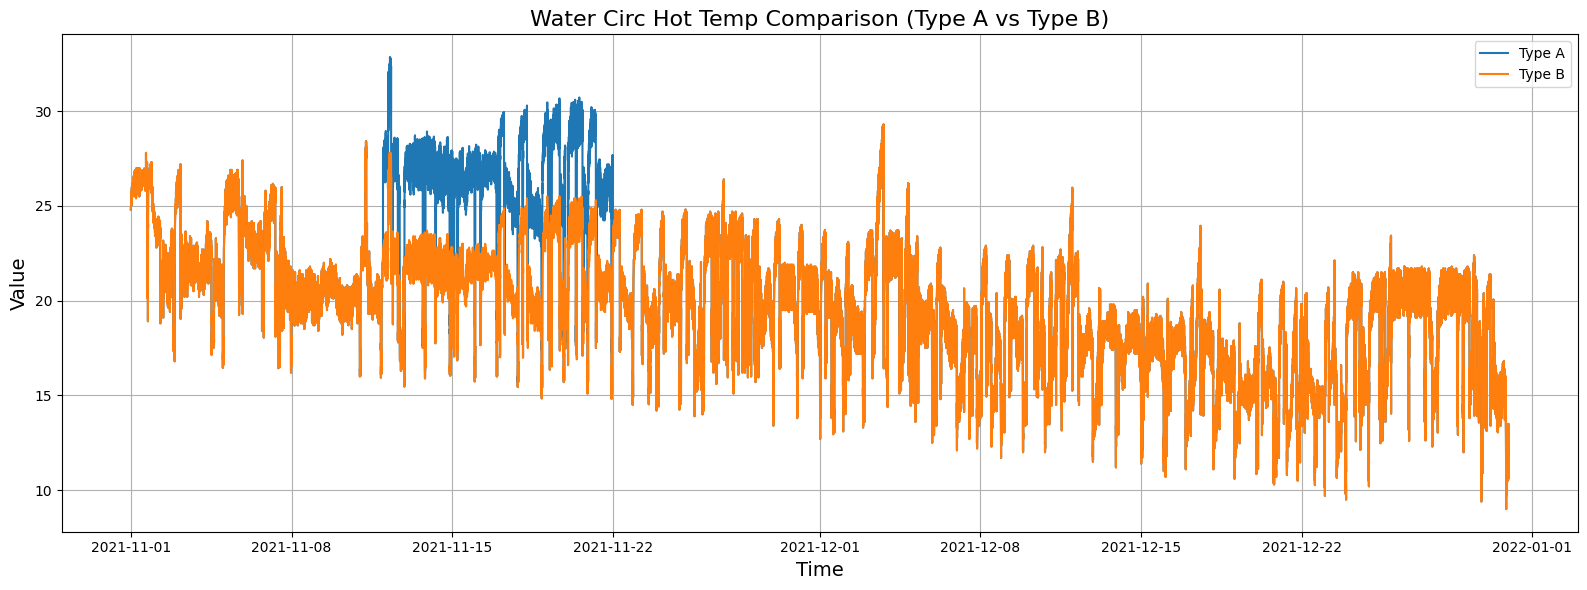

In [66]:
# Define the file paths
parquet_file_path_a = Path(dataset_root) / "synthetic_anomalies/VG5_anomaly_02_type_a.parquet"
parquet_file_path_b = Path(dataset_root) / "synthetic_anomalies/VG5_anomaly_02_type_b.parquet"

# Initialize lists to store data and labels
datasets = []
labels = ['Type A', 'Type B']

# Load the datasets
if parquet_file_path_a.exists():
    data_a = pd.read_parquet(parquet_file_path_a)
    if 'water_circ_hot_tmp' in data_a.columns:
        datasets.append(data_a['water_circ_hot_tmp'])
    else:
        print("'water_circ_hot_tmp' not found in Type A dataset.")
else:
    print(f"File not found: {parquet_file_path_a}")

if parquet_file_path_b.exists():
    data_b = pd.read_parquet(parquet_file_path_b)
    if 'water_circ_hot_tmp' in data_b.columns:
        datasets.append(data_b['water_circ_hot_tmp'])
    else:
        print("'water_circ_hot_tmp' not found in Type B dataset.")
else:
    print(f"File not found: {parquet_file_path_b}")

# Plot the datasets
if datasets:
    plt.figure(figsize=(16, 6))
    
    for i, dataset in enumerate(datasets):
        plt.plot(dataset, label=labels[i])
    
    plt.title('Water Circ Hot Temp Comparison (Type A vs Type B)', fontsize=16)
    plt.xlabel('Time', fontsize=14)
    plt.ylabel('Value', fontsize=14)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Plotting

# OPTUNA STUDY

---

### Rendered Markdown
When rendered, it will look like this:

To copy the `optuna` and `optuna_results` directories, you can use the following commands:

```bash
scp -r wan@scitas.epfl.ch:opp/optuna ./
scp -r wan@scitas.epfl.ch:opp/optuna_results ./

###  Uploading a file

# In WSL, navigate to where your hyperparam_tuning.py is located
cd /mnt/c/Users/Jiasheng/OneDrive/Documents/EPFL/ML\ for\ PREDICTIVE\ MAINTENANCE/Project/MLPM/SERVERFILES

# Upload to SCITAS
scp hyperparam_tuning.py wan@scitas.epfl.ch:opp/

In [ ]:
# Load the study with the correct database file
study = optuna.load_study(
    storage=f'sqlite:///optuna_results/study_20241201_111112.db',
    study_name='cnn_hyperopt_20241201_111112'  # or the study name might include the timestamp
)

# Print study information
print(f"\nNumber of trials: {len(study.trials)}")
print(f"Best value achieved: {study.best_value}")
print("\nBest parameters:")
for key, value in study.best_trial.params.items():
    print(f"{key}: {value}")


Number of trials: 10
Best value achieved: 0.0002610013179946691

Best parameters:
n_layers: 3
n_ch: 34
n_k: 9
n_hidden: 268
activation: relu
dropout: 0.006860848750797066
use_batchnorm: False
base_lr: 2.6086046890402925e-05
weight_decay: 8.394477725987022e-05


In [ ]:
# Visualizations
fig = optuna.visualization.plot_param_importances(study)
fig.show()

In [ ]:
fig = optuna.visualization.plot_contour(study, params=['base_lr', 'n_layers'])
fig.show()

In [ ]:
fig = optuna.visualization.plot_contour(study, params=['n_hidden', 'n_layers'])
fig.show()

In [ ]:
# Load results into DataFrame
hyper_df = study.trials_dataframe()
display(hyper_df)

,number,value,datetime_start,datetime_complete,duration,params_activation,params_base_lr,params_dropout,params_n_ch,params_n_hidden,params_n_k,params_n_layers,params_use_batchnorm,params_weight_decay,state
0,0,0.001290,2024-12-01 11:11:13.069097,2024-12-01 12:00:08.974889,0 days 00:48:55.905792,relu,0.000213,0.137849,75,79,5,5,False,0.000001,COMPLETE
1,1,0.000925,2024-12-01 12:00:08.995585,2024-12-01 13:16:54.580169,0 days 01:16:45.584584,leaky_relu,0.000023,0.071957,38,80,5,5,False,0.000002,COMPLETE
2,2,0.000261,2024-12-01 13:16:54.599148,2024-12-01 14:19:51.866436,0 days 01:02:57.267288,relu,0.000026,0.006861,34,268,9,3,False,0.000084,COMPLETE
3,3,0.001283,2024-12-01 14:19:51.886138,2024-12-01 15:07:43.931082,0 days 00:47:52.044944,leaky_relu,0.000014,0.210386,60,207,7,5,False,0.000002,COMPLETE
4,4,0.005409,2024-12-01 15:07:43.947612,2024-12-01 15:54:30.142941,0 days 00:46:46.195329,relu,0.000458,0.348953,86,111,9,3,False,0.000001,COMPLETE
5,5,0.027107,2024-12-01 15:54:30.161655,2024-12-01 16:43:43.696511,0 days 00:49:13.534856,leaky_relu,0.004271,0.327912,79,65,9,5,True,0.000686,COMPLETE
6,6,0.043565,2024-12-01 16:43:43.713767,2024-12-01 17:31:58.573875,0 days 00:48:14.860108,relu,0.000015,0.336235,57,345,7,6,False,0.000004,COMPLETE
7,7,0.000474,2024-12-01 17:31:58.606961,2024-12-01 18:16:19.285063,0 days 00:44:20.678102,relu,0.000014,0.163792,47,65,5,2,False,0.000049,COMPLETE
8,8,0.000399,2024-12-01 18:16:19.303124,2024-12-01 19:03:37.735585,0 days 00:47:18.432461,leaky_relu,0.000033,0.191441,93,130,9,5,False,0.000048,COMPLETE
9,9,0.000332,2024-12-01 19:03:37.752548,2024-12-01 19:48:07.853787,0 days 00:44:30.101239,leaky_relu,0.000025,0.333071,122,144,9,2,False,0.000053,COMPLETE
